In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.8)
plt.rcParams['figure.figsize'] = [14, 8]

In [22]:
# Configuration
BASE_DIR = '../profiling/results/nsys'
TIMESTAMP = '20260103_142952' 

# Map user friendly names to folder names
IMPLEMENTATIONS = {
    'optimized-cuda': 'optimized-cuda',
    'sparse-cuda': 'sparse-cuda',
    'naive-cuda-mpi:linear': 'naive-cuda-mpi-linear',
    'naive-cuda-mpi:louvain': 'naive-cuda-mpi-louvain',
    'naive-cuda-mpi:red-blue': 'naive-cuda-mpi-rb',
    'optimized-cuda-mpi:linear': 'optimized-cuda-mpi-linear',
    'optimized-cuda-mpi:louvain': 'optimized-cuda-mpi-louvain',
    'optimized-cuda-mpi:red-blue': 'optimized-cuda-mpi-red-blue'
}

# Define groups for analysis
CUDA_IMPLS = ['optimized-cuda', 'sparse-cuda']
MPI_IMPLS = [k for k in IMPLEMENTATIONS.keys() if 'mpi' in k]
ALL_IMPLS = list(IMPLEMENTATIONS.keys())

In [23]:
def load_nsys_csv(impl_name, report_type):
    folder = IMPLEMENTATIONS.get(impl_name, impl_name)
    path = os.path.join(BASE_DIR, TIMESTAMP, folder)
    # Look for files ending with the report type
    pattern = os.path.join(path, f"*{report_type}.csv")
    files = glob.glob(pattern)
    
    if not files:
        # Try searching recursively or just warn
        print(f"Warning: No file found for {impl_name} {report_type} in {path}")
        return None
        
    # Prefer rank0 if multiple files exist (common in MPI)
    rank0_files = [f for f in files if 'rank0' in f]
    file_to_load = rank0_files[0] if rank0_files else files[0]
    
    try:
        df = pd.read_csv(file_to_load)
        df['Implementation'] = impl_name
        return df
    except Exception as e:
        print(f"Error loading {file_to_load}: {e}")
        return None

def get_total_time_from_summary(df, time_col='Total Time (ns)'):
    if df is not None and time_col in df.columns:
        return df[time_col].sum()
    return 0

## CUDA Implementations Analysis

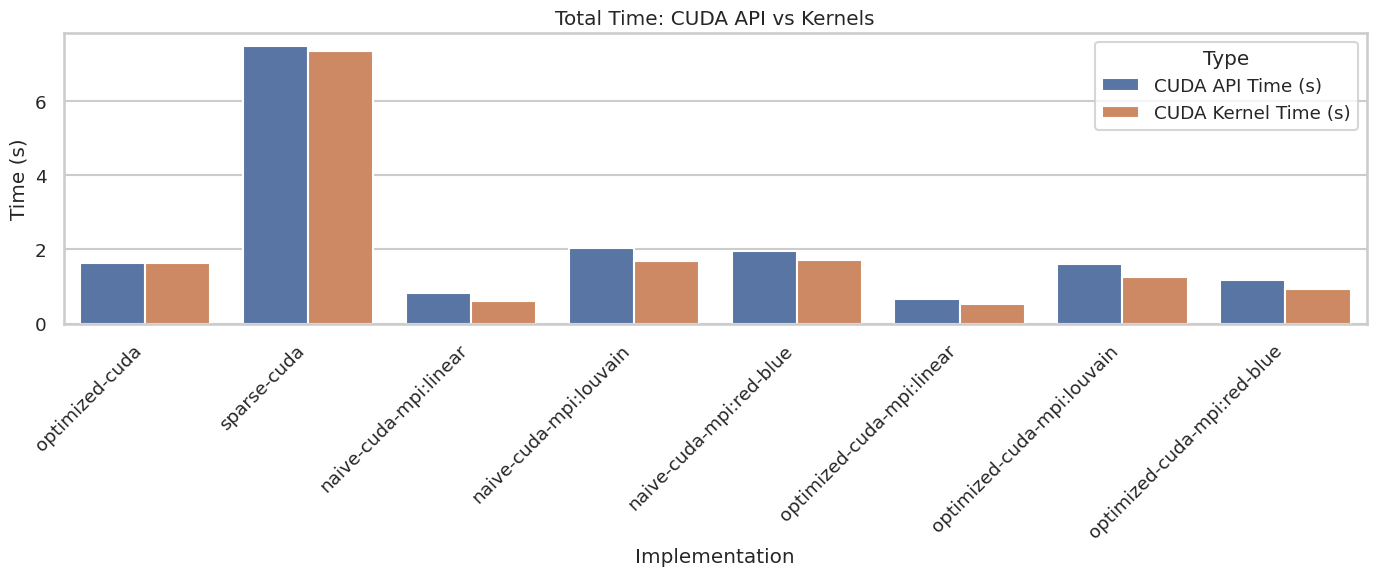

In [24]:
# 1. Time spent on CUDA API vs CUDA Kernels
# We will approximate this by summing total time in api_sum and gpu_kern_sum
# Note: API time includes synchronization which might overlap with kernels or idle time.

api_times = []
kernel_times = []
impls = []

for impl in ALL_IMPLS:
    df_api = load_nsys_csv(impl, 'cuda_api_sum')
    df_kern = load_nsys_csv(impl, 'cuda_gpu_kern_sum')
    
    if df_api is not None and df_kern is not None:
        impls.append(impl)
        api_times.append(get_total_time_from_summary(df_api) / 1e9) # Convert to seconds
        kernel_times.append(get_total_time_from_summary(df_kern) / 1e9)

df_time = pd.DataFrame({
    'Implementation': impls,
    'CUDA API Time (s)': api_times,
    'CUDA Kernel Time (s)': kernel_times
})

df_melted = df_time.melt(id_vars='Implementation', var_name='Type', value_name='Time (s)')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Implementation', y='Time (s)', hue='Type')
plt.xticks(rotation=45, ha='right')
plt.title('Total Time: CUDA API vs Kernels')
plt.tight_layout()
plt.show()

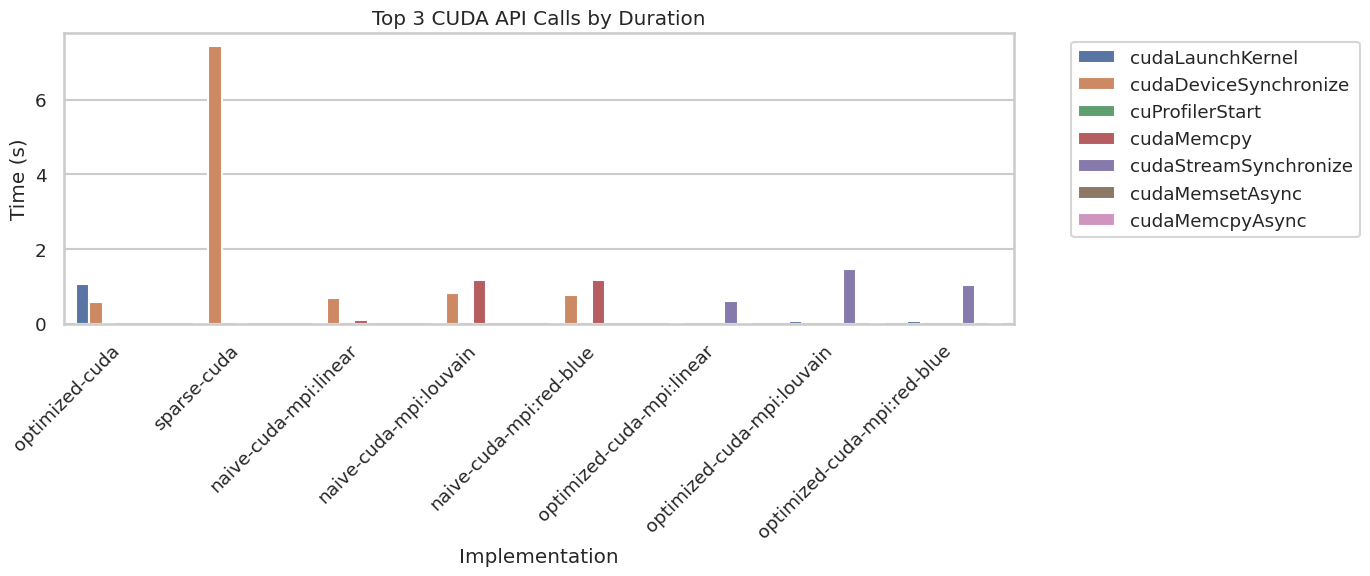

In [25]:
# 2. Time spent on CUDA API (Detailed)
# We'll look at the breakdown of API calls for each implementation

dfs = []
for impl in ALL_IMPLS:
    df = load_nsys_csv(impl, 'cuda_api_sum')
    if df is not None:
        # Get top 3 API calls by time
        top_api = df.sort_values('Total Time (ns)', ascending=False).head(3).copy()
        top_api['Time (s)'] = top_api['Total Time (ns)'] / 1e9
        dfs.append(top_api)

if dfs:
    df_api_breakdown = pd.concat(dfs)
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_api_breakdown, x='Implementation', y='Time (s)', hue='Name')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 3 CUDA API Calls by Duration')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

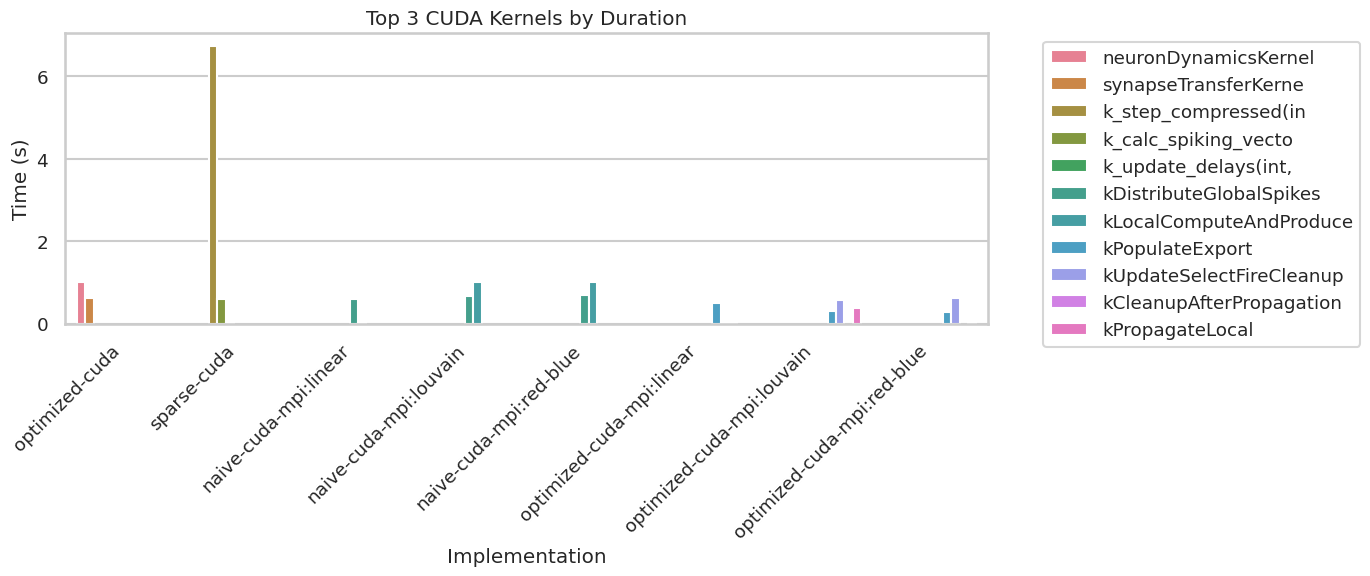

In [26]:
# 3. Time spent per Kernel
# We'll look at the breakdown of Kernels for each implementation

dfs = []
for impl in ALL_IMPLS:
    df = load_nsys_csv(impl, 'cuda_gpu_kern_sum')
    if df is not None:
        # Get top 3 Kernels by time
        # Clean up kernel names for better display
        # Or maybe use regex to extract the function name
        df['Kernel Name Short'] = df['Name'].str.extract(r'::(\w+)\(')
        df['Kernel Name Short'] = df['Kernel Name Short'].fillna(df['Name'].str.slice(0, 20))
        
        top_kern = df.sort_values('Total Time (ns)', ascending=False).head(3).copy()
        top_kern['Time (s)'] = top_kern['Total Time (ns)'] / 1e9
        dfs.append(top_kern)

if dfs:
    df_kern_breakdown = pd.concat(dfs)
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_kern_breakdown, x='Implementation', y='Time (s)', hue='Kernel Name Short')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 3 CUDA Kernels by Duration')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

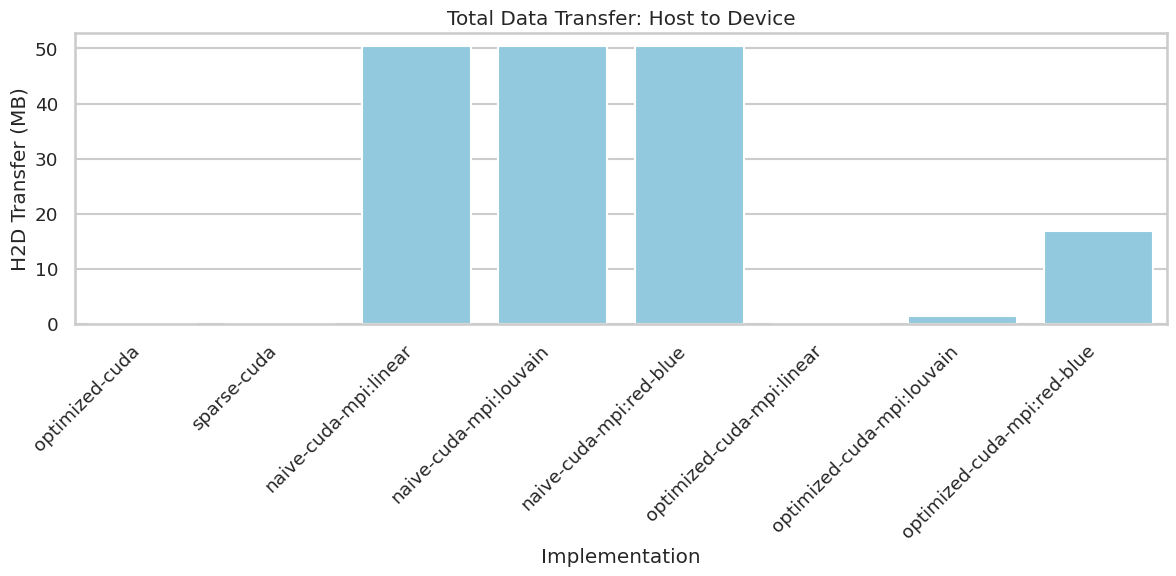

In [27]:
# 4. Data Transferred Host to Device
# Using cuda_gpu_mem_size_sum

h2d_sizes = []
impls_mem = []

for impl in ALL_IMPLS:
    df = load_nsys_csv(impl, 'cuda_gpu_mem_size_sum')
    if df is not None:
        # Filter for Host-to-Device
        # The operation name usually contains "Host-to-Device"
        h2d = df[df['Operation'].str.contains('Host-to-Device', case=False, na=False)]
        total_mb = h2d['Total (MB)'].sum()
        
        impls_mem.append(impl)
        h2d_sizes.append(total_mb)

df_mem = pd.DataFrame({
    'Implementation': impls_mem,
    'H2D Transfer (MB)': h2d_sizes
})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_mem, x='Implementation', y='H2D Transfer (MB)', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Total Data Transfer: Host to Device')
plt.tight_layout()
plt.show()

## MPI Implementations Analysis

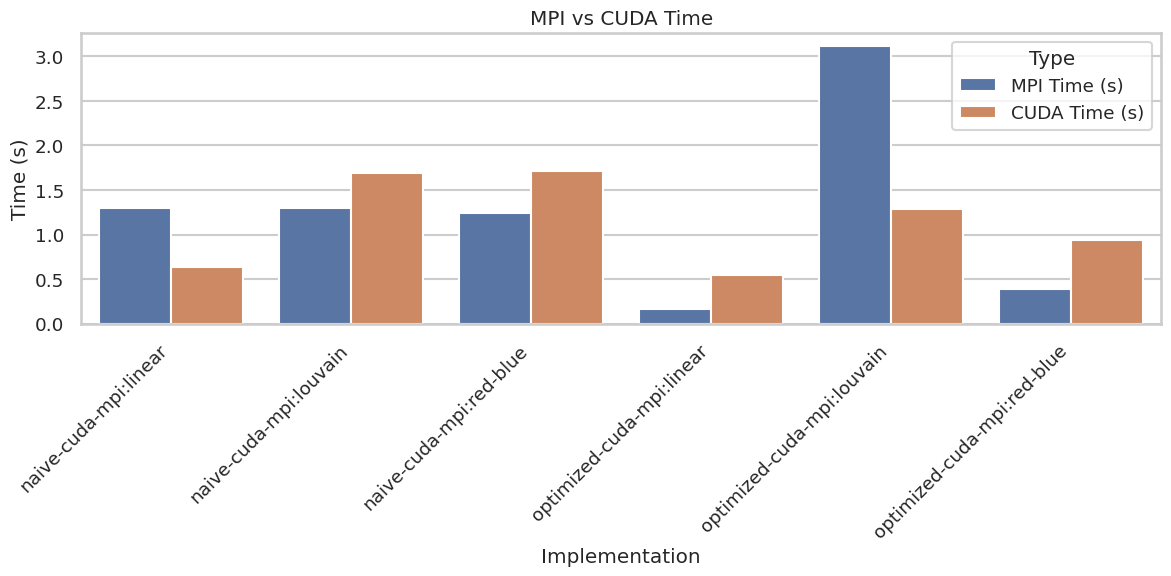

In [28]:
# 1. Time spent on CUDA vs MPI
# Comparing Total Kernel Time vs Total MPI Event Time

mpi_times = []
cuda_times = []
mpi_impls_found = []

for impl in MPI_IMPLS:
    df_mpi = load_nsys_csv(impl, 'mpi_event_sum')
    df_cuda = load_nsys_csv(impl, 'cuda_gpu_sum') # Total GPU activity
    
    if df_mpi is not None and df_cuda is not None:
        mpi_impls_found.append(impl)
        mpi_times.append(get_total_time_from_summary(df_mpi) / 1e9)
        cuda_times.append(get_total_time_from_summary(df_cuda) / 1e9)

df_mpi_cuda = pd.DataFrame({
    'Implementation': mpi_impls_found,
    'MPI Time (s)': mpi_times,
    'CUDA Time (s)': cuda_times
})

df_mc_melted = df_mpi_cuda.melt(id_vars='Implementation', var_name='Type', value_name='Time (s)')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_mc_melted, x='Implementation', y='Time (s)', hue='Type')
plt.xticks(rotation=45, ha='right')
plt.title('MPI vs CUDA Time')
plt.tight_layout()
plt.show()

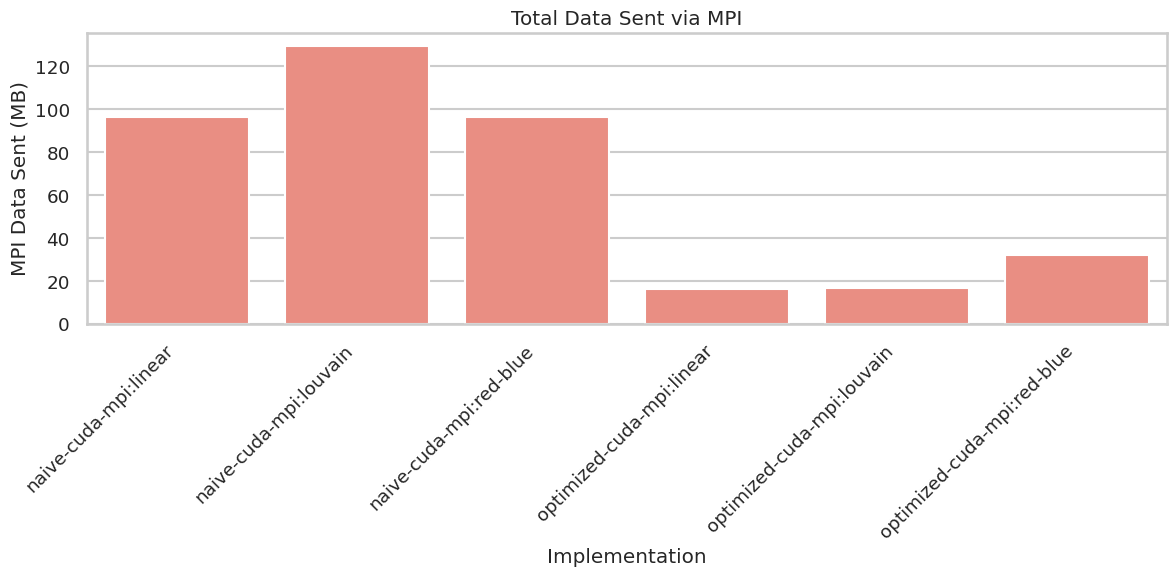

In [29]:
# 2. Data Sent through MPI
# Using mpi_msg_size_sum

mpi_data = []
mpi_impls_data = []

for impl in MPI_IMPLS:
    df = load_nsys_csv(impl, 'mpi_msg_size_sum')
    if df is not None:
        # Sum Total Message Volume
        # Usually in Bytes? The CSV header says "Total Message Volume". 
        # Let's assume Bytes.
        total_vol = df['Total Message Volume'].sum()
        
        mpi_impls_data.append(impl)
        mpi_data.append(total_vol / 1024 / 1024) # Convert to MB

df_mpi_vol = pd.DataFrame({
    'Implementation': mpi_impls_data,
    'MPI Data Sent (MB)': mpi_data
})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_mpi_vol, x='Implementation', y='MPI Data Sent (MB)', color='salmon')
plt.xticks(rotation=45, ha='right')
plt.title('Total Data Sent via MPI')
plt.tight_layout()
plt.show()

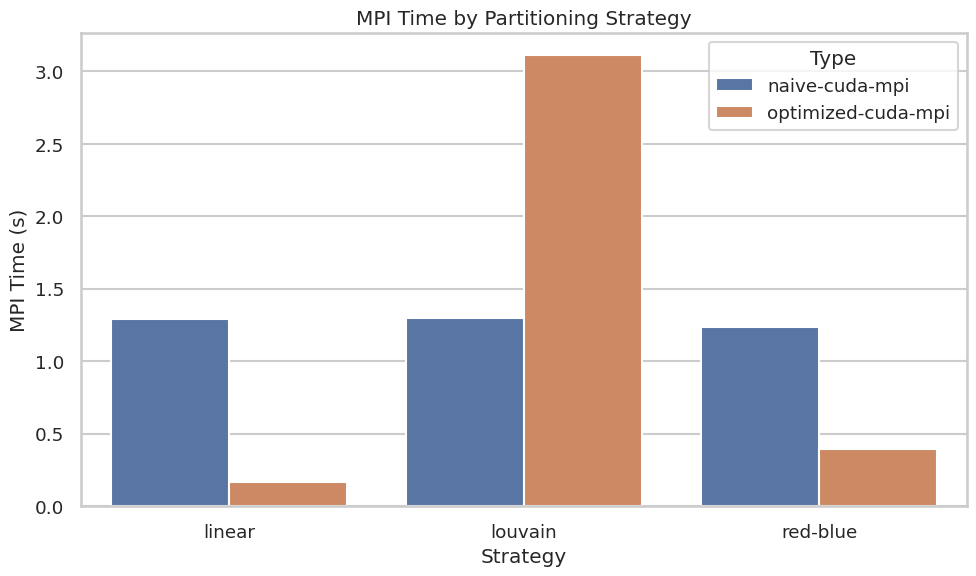

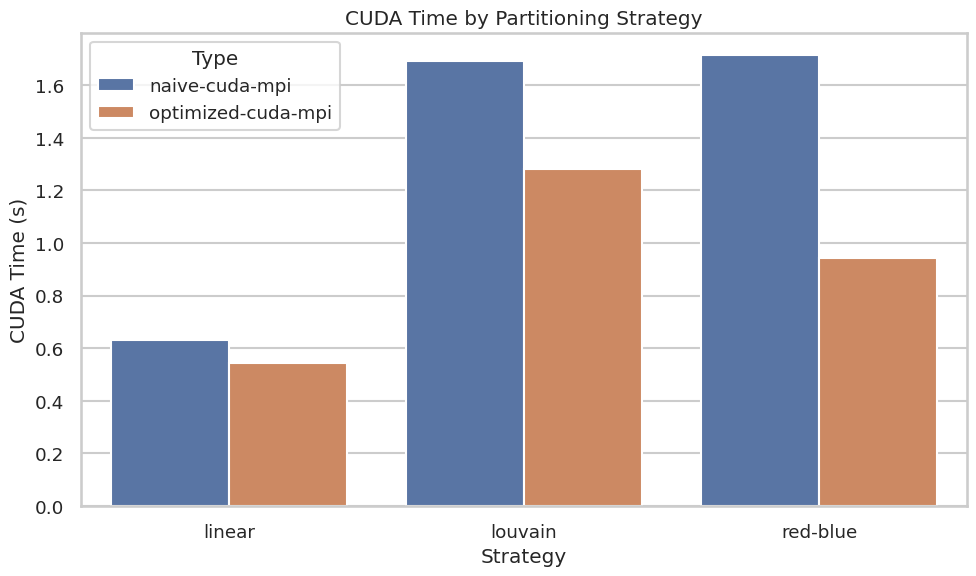

In [30]:
# 3. Compare Partitioning Strategies
# We will group by partitioning strategy (linear, louvain, red-blue)
# and compare MPI Time and CUDA Time

strategies = ['linear', 'louvain', 'red-blue']
metrics = []

for strat in strategies:
    # Find implementations with this strategy
    # We have naive and optimized versions
    for prefix in ['naive-cuda-mpi', 'optimized-cuda-mpi']:
        impl_name = f"{prefix}:{strat}"
        if impl_name in IMPLEMENTATIONS:
            df_mpi = load_nsys_csv(impl_name, 'mpi_event_sum')
            df_cuda = load_nsys_csv(impl_name, 'cuda_gpu_sum')
            
            mpi_t = get_total_time_from_summary(df_mpi) / 1e9 if df_mpi is not None else 0
            cuda_t = get_total_time_from_summary(df_cuda) / 1e9 if df_cuda is not None else 0
            
            metrics.append({
                'Strategy': strat,
                'Type': prefix,
                'MPI Time (s)': mpi_t,
                'CUDA Time (s)': cuda_t
            })

df_strat = pd.DataFrame(metrics)

# Plot MPI Time Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=df_strat, x='Strategy', y='MPI Time (s)', hue='Type')
plt.title('MPI Time by Partitioning Strategy')
plt.tight_layout()
plt.show()

# Plot CUDA Time Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=df_strat, x='Strategy', y='CUDA Time (s)', hue='Type')
plt.title('CUDA Time by Partitioning Strategy')
plt.tight_layout()
plt.show()